In [1]:
import torch
print("PyTorch 版本:", torch.__version__)
print("CUDA 是否可用:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA 版本:", torch.version.cuda)
    print("cuDNN 版本:", torch.backends.cudnn.version())

PyTorch 版本: 2.5.0+cu124
CUDA 是否可用: True
CUDA 版本: 12.4
cuDNN 版本: 90100


In [2]:
import torch
print(torch)


<module 'torch' from '/root/miniconda3/lib/python3.12/site-packages/torch/__init__.py'>


In [3]:
! python --version

Python 3.12.3


In [4]:
import flash_attn
print("FlashAttention 版本:", flash_attn.__version__)
import flash_attn_2_cuda


FlashAttention 版本: 2.7.4.post1


In [5]:
import xformers
print("xFormers 版本:", xformers.__version__)

xFormers 版本: 0.0.28.post2


In [6]:
from src.utils.file_utils import find_latest_model_path

In [7]:
find_latest_model_path('Classifier')
find_latest_model_path('ClfAttnPl')

Found folder: checkpoints/classifier_20250604-134716
Found folder: checkpoints/clfattnpl_20250528-153555


'/root/autodl-tmp/chuandian_eq/checkpoints/clfattnpl_20250528-153555'

In [8]:
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    CosineAnnealingWarmRestarts,
    CyclicLR,
    ExponentialLR,
    LambdaLR,
    MultiStepLR,
    ReduceLROnPlateau,
    StepLR,
    SequentialLR
)
# issubclass(StepLR, ReduceLROnPlateau)  # False
issubclass(SequentialLR, ReduceLROnPlateau)  # False


False

In [9]:
import src.data.catalog as catalog
import src.catalogs.cd as cd
import src.catalogs.s2 as s2
import src.catalogs.chuandian as chuandian  
catalog.Catalog.list_available()

['CD-Base',
 'CD-Standard',
 'CD-SlidingWindow',
 'S2-Base',
 'S2-Standard',
 'S2-SlidingWindow',
 'ChuanDian-Base',
 'ChuanDian-Standard',
 'ChuanDian-SlidingWindow']

In [10]:
CD_standard = catalog.Catalog.by_name("S2-Standard",)
CD_catalog = CD_standard(
    root_dir="/root/autodl-tmp/chuandian_eq/data/S2/raw",
    catalog_file="/root/autodl-tmp/chuandian_eq/data/S2/raw/size_3k_stress_0.6_dyn_0.8_mm_5.5_dm_0.5_b_0.4_yr_20k_EQ.dat"
)

instantiating registered subclass S2-Standard of <class 'src.data.catalog.Catalog'>
Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/S2/raw.


/root/autodl-tmp/chuandian_eq/src/data/catalog.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.norm_stats = torch.load(norm_path)
/root/autodl-tmp/chuandian_eq/src

In [11]:
CD_catalog.full_sequence

Sequence(
  inter_times: [136453],
  arrival_times: [136452],
  t_start: 0.0,
  t_end: 19886.0,
  t_nll_start: 0.0,
  mag: [136452],
  latitude: [136452],
  longitude: [136452],
  depth: [136452]
)

In [12]:
dl_train = CD_catalog.train.get_dataloader(batch_size=3)
for batch in dl_train:
    # print(batch['arrival_times'])
    # dif_times = batch['arrival_times'][:, 1:] - batch['arrival_times'][:, :-1]
    # print(batch['inter_times'])
    # print((batch['inter_times'][:, 1:] - dif_times).abs().max())

    # print(dif_times)
    print(batch.nll_mask)
    

tensor([[0., 0., 0.,  ..., 1., 1., 0.]])


In [13]:
print(batch.arrival_times.shape)
print(batch.nll_mask)
print(batch.non_pad_mask)

torch.Size([1, 81403])
tensor([[0., 0., 0.,  ..., 1., 1., 0.]])
tensor([[1., 1., 1.,  ..., 1., 1., 0.]])


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

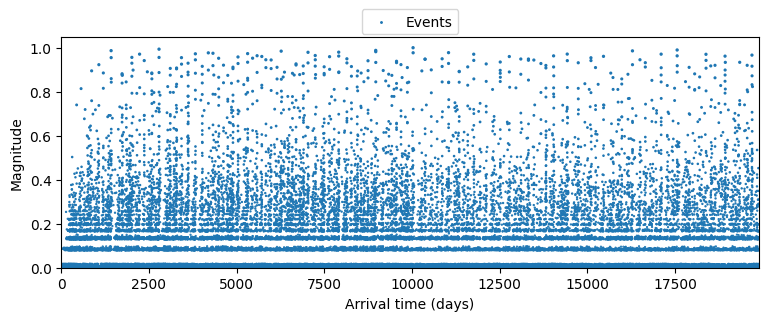

In [14]:
import src.catalogs.visualization as viz
viz.visualize_sequence(CD_catalog.full_sequence)

In [15]:
cd_sliding = cd.CDSlidingWindow(
    root_dir="/root/autodl-tmp/chuandian_eq/data/CD2021/raw",  # 用于存放生成的数据的目录
    catalog_file="/root/autodl-tmp/chuandian_eq/data/CD2021/raw/CD2021.dat",  # 原始地震目录数据
    mag_completeness=3.0,              # 最小震级阈值
    window_size_days=180,              # 滑动窗口大小（单位：天）
    step_size_days=30,                 # 滑动步长（单位：天）
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15
)


Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/CD2021/raw.
Generated 647 sliding window sequences.


In [16]:
cd_sliding.train[0].keys()
cd_sliding.train[0].t_start
cd_sliding.train[0].t_nll_start

5250.0

In [17]:
dl_train = cd_sliding.train.get_dataloader(batch_size=3)
for batch in dl_train:
    print(batch['arrival_times'])
    break

tensor([[5250.1147, 5250.4644, 5250.4658,  ..., 5430.0000, 5430.0000,
         5430.0000],
        [9451.2432, 9451.2520, 9451.3965,  ..., 9629.1484, 9629.4307,
         9630.0000],
        [4650.0132, 4650.0566, 4650.9180,  ..., 4830.0000, 4830.0000,
         4830.0000]])


In [18]:
batch.keys()

['inter_times',
 'arrival_times',
 't_start',
 't_end',
 't_nll_start',
 'nll_mask',
 'start_idx',
 'end_idx',
 'non_pad_mask',
 'type_seq',
 'mag',
 'latitude',
 'longitude',
 'depth']

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from src.models.SubLayers import ScaledSoftplus
from src.models.Layers import MLP, CNN, AttentionPooling
from src.models.dstpp.Models import Transformer, Transformer_ST, Transformer_STM, Transformer_SE


class THP(nn.Module):
    def __init__(self, args, device):
        super().__init__()
        self.device = device
        self.use_mc_samples = getattr(args, 'use_mc_samples', True)  # Use Monte Carlo samples for non-event LL
        self.pad_token_id = getattr(args, 'pad_token_id', -100)
        self.eps = torch.finfo(torch.float32).eps
        self.num_event_types = getattr(args, 'num_event_types', 1)
        self.loss_integral_num_sample_per_step = getattr(args, 'integral_num_sample', 100)  

        self.transformer = Transformer_ST(
            d_model=args.d_model,
            d_rnn=args.d_rnn,
            d_inner=args.d_inner,
            n_layers=args.n_layers,
            n_head=args.n_head,
            d_k=args.d_k,
            d_v=args.d_v,
            dropout=args.t_dropout,
            dropout_post_rnn = getattr(args, 'rnn_dropout', 0), 
            device=device,
            loc_dim=args.dim,
            CosSin=True,
            attn_type=args.attn_type,
        ).to(self.device)
        
       
        self.factor_intensity_base = nn.Parameter(torch.empty([1, self.num_event_types], device=self.device))
        self.factor_intensity_decay = nn.Parameter(torch.empty([1, self.num_event_types], device=self.device))
        nn.init.xavier_normal_(self.factor_intensity_base)
        nn.init.xavier_normal_(self.factor_intensity_decay)

        self.layer_intensity_hidden = nn.Linear(3*args.d_model, getattr(args, 'num_event_types', 1), bias=True)
        self.softplus = ScaledSoftplus(self.num_event_types)   # learnable mark-spe
    

    def forward(self, x):
        f_seq, t_n_seq = self._batch_to_model_input(x)
        enc_out, seq_mask  = self.transformer(f_seq[:,:-1,:], t_n_seq[:,:-1])
        return enc_out, seq_mask .squeeze(-1)
    
    def _build_type_seq(self, seq_mask):
        type_seq = torch.full_like(seq_mask, fill_value=self.pad_token_id, dtype=torch.long)
        type_seq[seq_mask.bool()] = 0
        return type_seq
    
    def log_likelihood(self, x):
        time_delta_seqs = x.inter_times
        enc_out, seq_mask = self.forward(x)
        type_seq = self._build_type_seq(seq_mask)

        factor_intensity_decay = self.factor_intensity_decay[None, ...]
        factor_intensity_base = self.factor_intensity_base[None, ...]
        intensity_states = factor_intensity_decay * time_delta_seqs[:, 1:, None] + self.layer_intensity_hidden(
            enc_out) + factor_intensity_base
        lambda_at_event = self.softplus(intensity_states)
        sample_dtimes = self.make_dtime_loss_samples(time_delta_seqs[:, 1:])

        state_t_sample = self.compute_states_at_sample_times(event_states=enc_out,
                                                             sample_dtimes=sample_dtimes)
        lambda_t_sample = self.softplus(state_t_sample)
        event_ll, non_event_ll, num_events = self.compute_loglikelihood(lambda_at_event=lambda_at_event,
                                                                        lambdas_loss_samples=lambda_t_sample,
                                                                        time_delta_seq=time_delta_seqs[:, 1:],
                                                                        seq_mask=seq_mask.long(),
                                                                        type_seq=type_seq.long())

        loss = - (event_ll - non_event_ll).sum()
        return loss, num_events

    def make_dtime_loss_samples(self, time_delta_seq):
        """Generate the time point samples for every interval.

        Args:
            time_delta_seq (tensor): [batch_size, seq_len].

        Returns:
            tensor: [batch_size, seq_len, n_samples]
        """
        # [1, 1, n_samples]
        dtimes_ratio_sampled = torch.linspace(start=0.0,
                                              end=1.0,
                                              steps=self.loss_integral_num_sample_per_step,
                                              device=self.device)[None, None, :]

        # [batch_size, max_len, n_samples]
        sampled_dtimes = time_delta_seq[:, :, None] * dtimes_ratio_sampled

        return sampled_dtimes
    


    def compute_states_at_sample_times(self, event_states, sample_dtimes):
        """Compute the hidden states at sampled times.

        Args:
            event_states (tensor): [batch_size, seq_len, hidden_size].
            sample_dtimes (tensor): [batch_size, seq_len, num_samples].

        Returns:
            tensor: hidden state at each sampled time.
        """
        # [batch_size, seq_len, 1, hidden_size]
        event_states = event_states[:, :, None, :]

        # [batch_size, seq_len, num_samples, 1]
        sample_dtimes = sample_dtimes[..., None]

        # [1, 1, 1, num_event_types]
        factor_intensity_decay = self.factor_intensity_decay[None, None, ...]
        factor_intensity_base = self.factor_intensity_base[None, None, ...]

        # update time decay based on Equation (6)
        # [batch_size, seq_len, num_samples, num_event_types]
        intensity_states = factor_intensity_decay * sample_dtimes + self.layer_intensity_hidden(
            event_states) + factor_intensity_base

        return intensity_states
    
    def compute_loglikelihood(self, time_delta_seq, lambda_at_event, lambdas_loss_samples, seq_mask, type_seq):
        """Compute the loglikelihood of the event sequence based on Equation (8) of NHP paper.

        Args:
            time_delta_seq (tensor): [batch_size, seq_len], time_delta_seq from model input.
            lambda_at_event (tensor): [batch_size, seq_len, num_event_types], unmasked intensity at
            (right after) the event.
            lambdas_loss_samples (tensor): [batch_size, seq_len, num_sample, num_event_types],
            intensity at sampling times.
            seq_mask (tensor): [batch_size, seq_len], sequence mask vector to mask the padded events.
            type_seq (tensor): [batch_size, seq_len], sequence of mark ids, with padded events having a mark of self.pad_token_id

        Returns:
            tuple: event loglike, non-event loglike, intensity at event with padding events masked
        """  
        # First, add an epsilon to every marked intensity for stability
        lambda_at_event = lambda_at_event + self.eps
        lambdas_loss_samples = lambdas_loss_samples + self.eps

        log_marked_event_lambdas = lambda_at_event.log()
        total_sampled_lambdas = lambdas_loss_samples.sum(dim=-1)

        # Compute event LL - [batch_size, seq_len]
        event_ll = -F.nll_loss(
            log_marked_event_lambdas.permute(0, 2, 1),  # mark dimension needs to come second, not third to match nll_loss specs
            target=type_seq,
            ignore_index=self.pad_token_id,  # Padded events have a pad_token_id as a value
            reduction='none', # Does not aggregate, and replaces what would have been the log(marked intensity) with 0.
        )

        # Compute non-event LL [batch_size, seq_len]
        # interval_integral = length_interval * average of sampled lambda(t)
        if self.use_mc_samples:
            non_event_ll = total_sampled_lambdas.mean(dim=-1) * time_delta_seq * seq_mask
        else: # Use trapezoid rule
            non_event_ll = 0.5 * (total_sampled_lambdas[..., 1:] + total_sampled_lambdas[..., :-1]).mean(dim=-1) * time_delta_seq * seq_mask

        num_events = torch.masked_select(event_ll, event_ll.ne(0.0)).size()[0]
        return event_ll, non_event_ll, num_events
    
    @staticmethod
    def _batch_to_model_input(bx):
        t_seq = bx.arrival_times
        t_delta_seqs = bx.inter_times
        mag_seq = bx.mag
        loc_seq = torch.concat((bx.latitude.unsqueeze(2), bx.longitude.unsqueeze(2)), dim=-1) 
        dep_seq = bx.depth
        f_seq = torch.concat((loc_seq, mag_seq.unsqueeze(2)), dim=-1)
        return f_seq, t_seq

2025-06-10 22:06:22.773645: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-10 22:06:22.788086: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749564382.804072    8476 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749564382.808912    8476 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749564382.821272    8476 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [20]:
from config.config_loader import load_args_from_yaml
args = load_args_from_yaml('config/Classifier.yaml')
args.attn_type = 'full'

In [21]:
thp_model = THP(args, device='cuda').to('cuda')

In [22]:
thp_model(batch.to('cuda'))

(tensor([[[-0.1078,  0.0196, -0.1207,  ...,  0.1056,  0.0906,  0.1054],
          [-0.1270,  0.0008, -0.1067,  ...,  0.1184,  0.0725,  0.1045],
          [-0.1254,  0.0113, -0.1179,  ...,  0.0896,  0.0692,  0.1219],
          ...,
          [-0.2187, -0.0225,  0.0162,  ...,  0.2969,  0.2524,  0.2091],
          [-0.2157, -0.0191,  0.0364,  ...,  0.3088,  0.2619,  0.2234],
          [-0.2196, -0.0000,  0.0386,  ...,  0.2876,  0.2635,  0.2338]],
 
         [[-0.1304,  0.0800, -0.1602,  ...,  0.1017, -0.0009,  0.2355],
          [-0.1541,  0.1001, -0.1978,  ...,  0.1112, -0.0298,  0.2863],
          [-0.1673,  0.0995, -0.2176,  ...,  0.1112, -0.0439,  0.3430],
          ...,
          [-0.1128,  0.0453, -0.1426,  ...,  0.1593, -0.0006,  0.2619],
          [-0.1321,  0.0297, -0.1308,  ...,  0.1454, -0.0023,  0.2587],
          [-0.1246,  0.0496, -0.1189,  ...,  0.1494, -0.0013,  0.2767]],
 
         [[-0.0994,  0.1666, -0.0967,  ...,  0.1439,  0.2158,  0.2321],
          [-0.0990,  0.2303,

In [23]:
thp_model.log_likelihood(batch.to('cuda'))

(tensor(-171.5139, device='cuda:0', grad_fn=<NegBackward0>), 2076)

In [24]:
optimizer = torch.optim.AdamW(thp_model.parameters(), lr=1e-3, weight_decay=1e-4)
for epoch in range(10):
    thp_model.train()
    for batch in dl_train:
        batch.to('cuda')
        optimizer.zero_grad()
        loss, num_events = thp_model.log_likelihood(batch)
        loss.backward()
        optimizer.step()
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: -172.16705322265625
Epoch 0, Loss: -640.9556884765625
Epoch 0, Loss: -373.8778076171875
Epoch 0, Loss: -1529.7686767578125
Epoch 0, Loss: -947.438232421875
Epoch 0, Loss: -856.416015625
Epoch 0, Loss: -4197.3349609375
Epoch 0, Loss: -4284.08935546875
Epoch 0, Loss: -3877.1923828125
Epoch 0, Loss: -3209.174072265625
Epoch 0, Loss: -3015.368896484375
Epoch 0, Loss: -585.489501953125
Epoch 0, Loss: -3854.05908203125
Epoch 0, Loss: -6462.62109375
Epoch 0, Loss: -1746.5872802734375
Epoch 0, Loss: -383.742919921875
Epoch 0, Loss: -412.41656494140625
Epoch 0, Loss: -1267.13671875
Epoch 0, Loss: -2927.607666015625
Epoch 0, Loss: -360.6835021972656
Epoch 0, Loss: -6899.81884765625
Epoch 0, Loss: -7418.36474609375
Epoch 0, Loss: -4298.92822265625
Epoch 0, Loss: -388.1773376464844
Epoch 0, Loss: -8185.49169921875
Epoch 0, Loss: -4105.482421875
Epoch 0, Loss: -9526.830078125
Epoch 0, Loss: -1164.447265625
Epoch 0, Loss: -1956.802734375
Epoch 0, Loss: -578.1453247070312
Epoch 0, Loss

Epoch 0, Loss: -2332.23486328125
Epoch 0, Loss: -2938.9033203125
Epoch 0, Loss: -484.6026916503906
Epoch 0, Loss: -3562.1962890625
Epoch 0, Loss: -452.83758544921875
Epoch 0, Loss: -3765.708984375
Epoch 0, Loss: -5766.67333984375
Epoch 0, Loss: -2983.28173828125
Epoch 0, Loss: 53.67145538330078
Epoch 0, Loss: -3085.36181640625
Epoch 0, Loss: -3461.26025390625
Epoch 0, Loss: -297.36810302734375
Epoch 0, Loss: -2519.04833984375
Epoch 0, Loss: -999.8232421875
Epoch 0, Loss: -3815.13232421875
Epoch 0, Loss: -3563.24951171875
Epoch 0, Loss: -490.6729736328125
Epoch 0, Loss: -721.1507568359375
Epoch 0, Loss: -2174.744140625
Epoch 0, Loss: -1081.2791748046875
Epoch 0, Loss: -2550.205810546875
Epoch 0, Loss: -3524.97607421875
Epoch 0, Loss: -2998.81298828125
Epoch 0, Loss: -429.66119384765625
Epoch 0, Loss: -866.4913330078125
Epoch 0, Loss: -860.567626953125
Epoch 0, Loss: -1424.9951171875
Epoch 0, Loss: -4601.0888671875
Epoch 0, Loss: -1739.2369384765625
Epoch 0, Loss: -3161.887939453125
Epoc

KeyboardInterrupt: 